<center> <h1> Fire v/s No Fire Detection Project </h1> </center>

In [1]:
#Import the dataset:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("phylake1337/fire-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Lenovo\.cache\kagglehub\datasets\phylake1337\fire-dataset\versions\1


In [2]:
#Import the required libraries:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split


#Ignore all incoming warnings (if any):
import warnings
warnings.filterwarnings("ignore")

In [3]:
with_fire_files = os.listdir("data/fire_images")
without_fire_files = os.listdir("data/non_fire_images")

print("Number of:")
print("\t\t With Fire Images = ",len(with_fire_files))
print("\t\t Without Fire Images = ",len(without_fire_files))

Number of:
		 With Fire Images =  755
		 Without Fire Images =  244


<center> <h5> At this point we can see that our data is imbalanced. Hence this imbalance will be addressed during model training.</h5> </center>

In [4]:
#Create labels for both classes:
with_fire_labels = [1]*len(with_fire_files)
without_fire_labels = [0]*len(without_fire_files)

In [5]:
#Check the labels:
print(with_fire_labels[:5])
print(without_fire_labels[:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


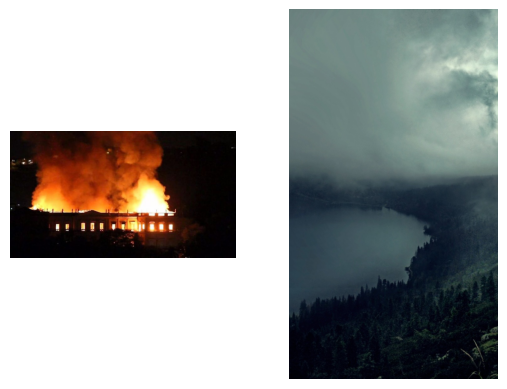

In [6]:
#Display one image from each class:
image1 = Image.open("data/fire_images/fire.15.png")
image2 = Image.open("data/non_fire_images/non_fire.11.png")

plt.subplot(1,2,1)
plt.imshow(image1)
plt.axis("off")   # hide axes

plt.subplot(1,2,2)
plt.imshow(image2)
plt.axis("off")   # hide axes
plt.show()

**CONCLUSION AT THIS POINT]** Image dimensions are not uniform.

**Image Preprocessing:**

1] Resize the images <br>
2] Convert the images to numpy arrays

In [7]:
#Preprocessing for with fire_images:
with_fire_path = "data/fire_images/"

data = []

for img_file in with_fire_files:
    image = Image.open(with_fire_path + img_file)
    image = image.resize((128,128))
    image = image.convert("RGB")
    image = np.array(image)
    data.append(image)





#Preprocessing for without_fire_images:
without_fire_path = "data/non_fire_images/"

for img_file in without_fire_files:
    image = Image.open(without_fire_path + img_file)
    image = image.resize((128,128))
    image = image.convert("RGB")
    image = np.array(image)
    data.append(image)

In [8]:
#View the first image:
data[0]

array([[[205, 209, 208],
        [204, 208, 207],
        [205, 209, 209],
        ...,
        [168, 162, 149],
        [166, 159, 146],
        [169, 165, 150]],

       [[204, 208, 207],
        [204, 208, 207],
        [205, 209, 209],
        ...,
        [168, 162, 148],
        [169, 162, 149],
        [171, 165, 151]],

       [[204, 208, 207],
        [204, 208, 207],
        [204, 208, 207],
        ...,
        [165, 157, 144],
        [167, 162, 148],
        [171, 164, 151]],

       ...,

       [[ 58,  47,  31],
        [ 52,  38,  28],
        [ 89,  75,  53],
        ...,
        [117,  84,  57],
        [103,  74,  54],
        [ 88,  70,  44]],

       [[ 66,  53,  41],
        [ 76,  57,  43],
        [ 74,  63,  48],
        ...,
        [ 89,  61,  42],
        [ 88,  65,  46],
        [ 97,  78,  48]],

       [[ 70,  55,  40],
        [100,  78,  59],
        [ 67,  58,  40],
        ...,
        [ 92,  64,  43],
        [ 59,  44,  31],
        [ 85,  69,  42]]

In [9]:
#Shape of the first image: (height,width,colorChannel)
data[0].shape

(128, 128, 3)

<h3> Machine Learning Part: </h3>

In [10]:
labels = with_fire_labels + without_fire_labels

X = np.array(data)
Y = np.array(labels)

In [11]:
X.shape

(999, 128, 128, 3)

In [12]:
Y.shape

(999,)

In [13]:
#Split your data into training and testing data:
X_train , X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

In [14]:
#Scale the data (for making the CNN neural network work better):
X_train_scaled = X_train/255
X_test_scaled = X_test/255

<h4> Building the CNN (Convolutional Neural Network): </h4>

In [15]:
import tensorflow as tf
from tensorflow import keras



model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3))) #we used 3 as the last parameter since we also have colored images and not only Gray-scale images
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())


#Create a dense layer:
model.add(keras.layers.Dense(128, activation='relu'))
#Prevent model being over-fitted:
model.add(keras.layers.Dropout(0.5))



#Create an another dense layer:
model.add(keras.layers.Dense(64, activation='relu'))
#Prevent model being over-fitted:
model.add(keras.layers.Dropout(0.5))


#Build the output layer:
model.add(keras.layers.Dense(1,activation='sigmoid'))

In [16]:
#Compile the neural network:
model.compile(
    optimizer='adam',
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [17]:
#Train the neural network:

from sklearn.utils.class_weight import compute_class_weight #since our dataset is imbalanced
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y_train),
    y=Y_train
)

# Convert to a dictionary that Keras expects
weight_dict = dict(enumerate(class_weights))

history = model.fit(X_train_scaled,Y_train,validation_split=0.1,epochs=10,class_weight=weight_dict) #'class_weight' parameter is used beacuse our dataset is imbalanced

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 242ms/step - accuracy: 0.7719 - loss: 0.4876 - val_accuracy: 0.9500 - val_loss: 0.1187
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 218ms/step - accuracy: 0.8873 - loss: 0.2563 - val_accuracy: 0.9375 - val_loss: 0.1816
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 248ms/step - accuracy: 0.9138 - loss: 0.2523 - val_accuracy: 0.8250 - val_loss: 0.3330
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 252ms/step - accuracy: 0.9096 - loss: 0.2049 - val_accuracy: 0.9500 - val_loss: 0.0857
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 244ms/step - accuracy: 0.9332 - loss: 0.1620 - val_accuracy: 0.9750 - val_loss: 0.0740
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step - accuracy: 0.9458 - loss: 0.1545 - val_accuracy: 0.9625 - val_loss: 0.1981
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 294ms/step - accuracy: 0.9513 - loss: 0.1093 - val_accuracy: 0.9750 - val_loss: 0.0891
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 284ms/step - accuracy: 0.9666 - loss: 0.0918 - val_accuracy: 0

<h4> Model Evaluation: </h4>

In [18]:
loss , accuracy = model.evaluate(X_test_scaled , Y_test)
print("Test Accuracy = ",accuracy*100,"%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9550 - loss: 0.1643
Test Accuracy =  95.49999833106995 %


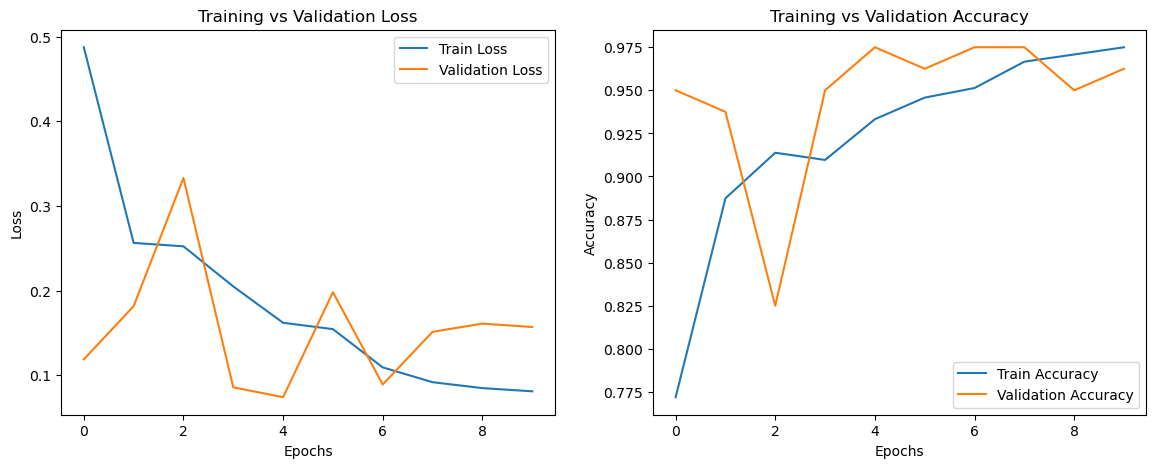

In [19]:
h = history

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
# Loss graph
plt.plot(h.history['loss'], label='Train Loss')
plt.plot(h.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
# Accuracy graph
plt.plot(h.history['accuracy'], label='Train Accuracy')
plt.plot(h.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

<center> <h3> Make Predictions using the model: </h3> </center>

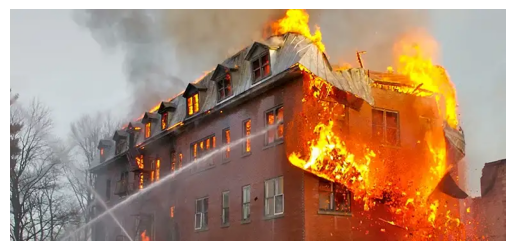

In [20]:
#Get the image:

import urllib.request

url = "https://wfmmedia.com/wp-content/uploads/2022/09/Need-for-Fire-Safe-Designs-and-Performance-Testing.webp"

img = Image.open(urllib.request.urlopen(url))

plt.imshow(img)
plt.axis("off")
plt.show()

In [21]:
#Convert the image into a numpy array:


def label_image(img):
    input_image = np.array(img)
    
    
    input_image_resized = cv2.resize(input_image, (128,128))
    input_image_scaled = input_image_resized / 255
    input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3]) #Make prediction for one image with dimension as (128,128,3)
    
    input_prediction = model.predict(input_image_reshaped)
    print(input_prediction)
    input_pred_label = round(input_prediction[0][0])
    print(input_pred_label)
    
    
    if input_pred_label > 0.5:
        print("There is fire.")
    else:
        print("There is no fire.")
        
label_image(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
[[0.99999994]]
1
There is fire.


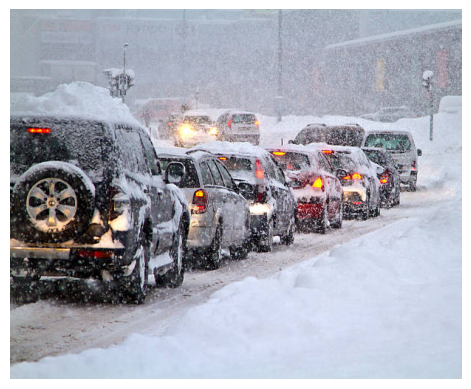

In [22]:
#Get another image and then make statement:
url = "https://media.istockphoto.com/id/518277863/photo/blizzard-on-the-road.jpg?s=612x612&w=0&k=20&c=_ieFOc5ZXd8gZgKyW_KCeSj9d8O7a7nSSGDZrs7msrM="

img = Image.open(urllib.request.urlopen(url))

plt.imshow(img)
plt.axis("off")
plt.show()

In [23]:
label_image(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
[[0.9910973]]
1
There is fire.


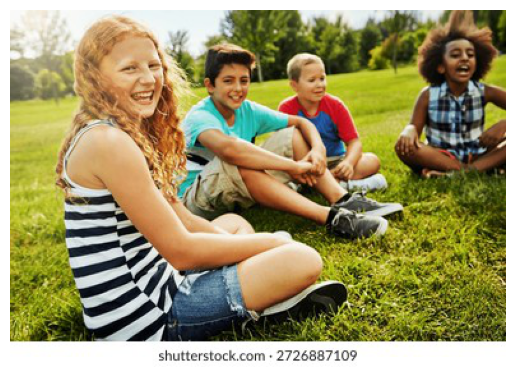

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
[[0.05599238]]
0
There is no fire.


In [24]:
url= "https://www.shutterstock.com/image-photo/laughing-friends-portrait-child-park-260nw-2726887109.jpg"
img = Image.open(urllib.request.urlopen(url))

plt.imshow(img)
plt.axis("off")
plt.show()

label_image(img)

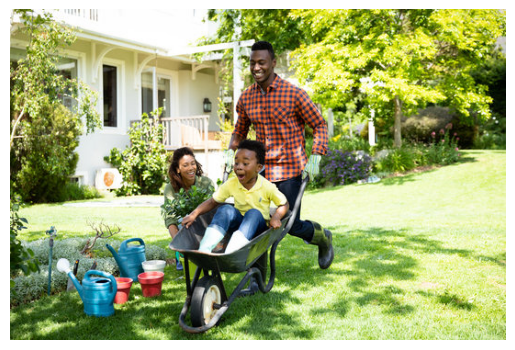

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
[[2.1483145e-05]]
0
There is no fire.


In [25]:
url= "https://t4.ftcdn.net/jpg/03/29/12/23/360_F_329122357_Z6xtkYb30Ts68q2xvW2D7cSZDCOgMJCl.jpg"
img = Image.open(urllib.request.urlopen(url))

plt.imshow(img)
plt.axis("off")
plt.show()

label_image(img)

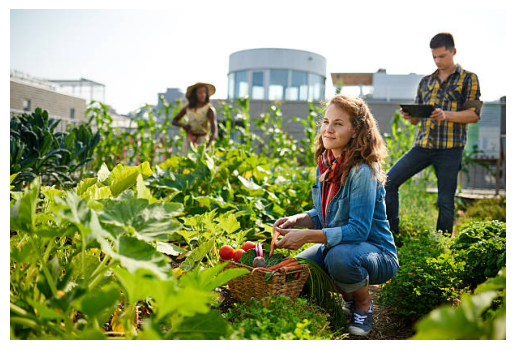

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
[[9.965801e-07]]
0
There is no fire.


In [26]:
url= "https://media.istockphoto.com/id/519738002/photo/friendly-team-harvesting-fresh-vegetables-from-the-rooftop-greenhouse-garden.jpg?s=612x612&w=0&k=20&c=k8MpaYzPZ-NRYKiQgkG-6-QKaRcH_miIuv1hWJJIs5o="
img = Image.open(urllib.request.urlopen(url))

plt.imshow(img)
plt.axis("off")
plt.show()

label_image(img)

<h3> Export the model: </h3>

In [27]:
import joblib
joblib.dump(model,"Fire_Detection_Model.pkl")

['Fire_Detection_Model.pkl']

**Project by:** <br>
**Name:** Om Satyawan Pathak<br>
**LinkedIn Profile:** www.linkedin.com/in/om-satyawan-pathak-029b02368<br>
**GitHub Profile:** https://github.com/omsatyawanpathakgit<br>